# 3. Risk and drawdowns

**Question:** how bad can it get, and for how long?

Five model portfolios are analysed on investable ETFs (2010 onwards), and three of them again on
the long-history proxies (1999 onwards), which include two major bear markets.

In [1]:
import warnings

import numpy as np
import pandas as pd

from investor_toolkit.plotting import apply_style

warnings.filterwarnings("ignore", category=FutureWarning)
apply_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
FIGURES = "../docs/figures"

from investor_toolkit import proxies, risk, universe
from investor_toolkit.diversification import portfolio_returns
from investor_toolkit.plotting import plot_lines

In [2]:
pd.DataFrame(
    [
        {"portfolio": p.name, "description": p.description}
        for p in universe.MODEL_PORTFOLIOS.values()
    ]
).set_index("portfolio")

,description
portfolio,
defensive,"25% global equity, 75% euro-area government bonds"
balanced,"60% global equity, 40% euro-area government bonds"
growth,100% global equity
diversified,"40% equity, 30% nominal bonds, 15% inflation-l..."
concentrated,Equal weights in five large German stocks


In [3]:
asset_returns = universe.load_asset_returns()
long = proxies.long_history()
cash = long["cash"].reindex(asset_returns.index).ffill()

ucits = pd.DataFrame(
    {
        name: portfolio_returns(asset_returns, p.weights)
        for name, p in universe.MODEL_PORTFOLIOS.items()
    }
)
history = pd.DataFrame(
    {
        name: portfolio_returns(long, p.weights)
        for name, p in universe.LONG_HISTORY_PORTFOLIOS.items()
    }
)
print(f"ETF sample: {ucits.index[0]:%Y-%m} to {ucits.index[-1]:%Y-%m}")
print(f"Long sample: {history.index[0]:%Y-%m} to {history.index[-1]:%Y-%m}")

ETF sample: 2009-12 to 2026-09
Long sample: 1999-02 to 2026-08


## Summary statistics

Sharpe and Sortino ratios use EUR cash as the risk-free rate. VaR and ES are monthly, at 95 %,
from the historical distribution, reported as positive losses.

In [4]:
risk.risk_summary(ucits, 12, cash)

,CAGR,volatility,sharpe,sortino,max_drawdown,calmar,ulcer_index,VaR_95%,ES_95%,worst_period
defensive,0.044,0.055,0.688,1.050,0.171,0.258,0.048,0.024,0.035,-0.045
balanced,0.084,0.082,0.945,1.541,0.154,0.546,0.041,0.033,0.049,-0.074
growth,0.129,0.124,0.986,1.638,0.188,0.686,0.047,0.054,0.074,-0.108
diversified,0.075,0.066,1.023,1.720,0.113,0.662,0.028,0.030,0.039,-0.058
concentrated,0.108,0.195,0.587,0.913,0.288,0.374,0.098,0.077,0.117,-0.200


In [5]:
risk.risk_summary(history, 12, long["cash"])

,CAGR,volatility,sharpe,sortino,max_drawdown,calmar,ulcer_index,VaR_95%,ES_95%,worst_period
defensive,0.042,0.056,0.452,0.683,0.202,0.206,0.052,0.023,0.033,-0.056
balanced,0.061,0.087,0.526,0.775,0.290,0.209,0.090,0.043,0.055,-0.089
growth,0.079,0.141,0.490,0.708,0.525,0.151,0.191,0.075,0.092,-0.138


The same allocations look very different in the two samples. The ETF era (from 2010) contains no
deep equity bear market, so drawdowns are mild. Over the longer history, the all-equity portfolio
lost about half its value from the 2000 peak. Judging risk from the recent sample alone would
understate it.

## Drawdowns

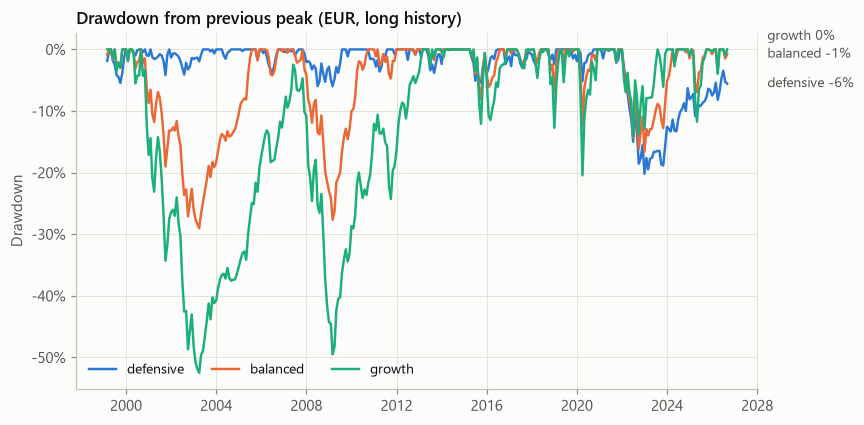

In [6]:
underwater = history.apply(risk.drawdown)
ax = plot_lines(
    underwater,
    title="Drawdown from previous peak (EUR, long history)",
    percent=True,
    label_fmt=lambda v: f"{v:.0%}",
    legend_loc="lower left",
)
ax.set_ylabel("Drawdown")
ax.figure.savefig(f"{FIGURES}/drawdowns.png")

In [7]:
pd.concat(
    {name: risk.drawdown_episodes(history[name], top=3) for name in history},
    names=["portfolio", "rank"],
)

peak     trough   recovery  depth  to_trough  under_water
portfolio rank                                                                
defensive 0    2021-11-30 2022-12-31        NaT  0.202         13           57
          1    2007-10-31 2008-06-30 2009-07-31  0.060          8           21
          2    1999-04-30 1999-09-30 1999-12-31  0.055          5            8
balanced  0    2000-08-31 2003-03-31 2005-07-31  0.290         31           59
          1    2007-05-31 2009-02-28 2010-09-30  0.276         21           40
          2    2021-12-31 2022-12-31 2024-03-31  0.166         12           27
growth    0    2000-08-31 2003-03-31 2013-02-28  0.525         31          150
          1    2020-01-31 2020-03-31 2020-11-30  0.204          2           10
          2    2021-12-31 2022-06-30 2023-12-31  0.142          6           24

`under_water` is the number of months from the previous peak until it is regained. Depth is only
half of the story: after the 2000 peak, an all-equity EUR investor needed well over a decade to
recover in nominal terms, while bond-heavy portfolios recovered within a few years.

For comparison, driftless Brownian motion has an expected maximum drawdown of
$\sqrt{\pi/2}\,\sigma\sqrt{T}$ in log terms (Magdon-Ismail et al., 2004). This is an upper
reference for a zero-return asset with the same volatility; a positive drift reduces it.

In [8]:
rows = {}
for name in history:
    sigma = np.log1p(history[name]).std() * np.sqrt(12)
    years = len(history) / 12
    rows[name] = {
        "observed_max_drawdown": risk.max_drawdown(history[name]),
        "driftless_BM_expectation": 1 - np.exp(-risk.expected_max_drawdown_brownian(sigma, years)),
    }
pd.DataFrame(rows).T

,observed_max_drawdown,driftless_BM_expectation
defensive,0.202,0.308
balanced,0.290,0.435
growth,0.525,0.607


## Value at Risk and Expected Shortfall

VaR is the loss exceeded with probability $\alpha$; ES is the average loss in that worst
$\alpha$ tail. Four VaR methods are compared on the all-equity long-history portfolio.

In [9]:
risk.var_table(history["growth"])

VaR     ES
confidence method                      
95%        historical      0.075  0.092
           gaussian        0.060  0.077
           cornish_fisher  0.065    NaN
           student_t       0.056  0.082
99%        historical      0.101  0.114
           gaussian        0.088  0.101
           cornish_fisher  0.106    NaN
           student_t       0.097  0.129

**Backtesting the VaR.** A useful VaR model is tested out of sample: estimate VaR from the past
five years, record whether next month's loss exceeds it, and roll forward. The Kupiec test
checks whether exceptions occur at the promised rate; the Christoffersen test checks whether
they cluster.

In [10]:
rows = []
for alpha in (0.05, 0.01):
    for method in risk.VAR_METHODS:
        bt = risk.backtest_var(history["growth"], window=60, alpha=alpha, method=method)
        rows.append(
            {
                "confidence": f"{1 - alpha:.0%}",
                "method": method,
                "expected_rate": alpha,
                "observed_rate": bt["exception"].mean(),
                "kupiec_p": risk.kupiec_test(bt["exception"], alpha)[1],
                "christoffersen_p": risk.christoffersen_test(bt["exception"])[1],
            }
        )
pd.DataFrame(rows).set_index(["confidence", "method"])

expected_rate  observed_rate   kupiec_p  christoffersen_p
confidence method                                                                   
95%        historical               0.05          0.074  9.213e-02             0.056
           gaussian                 0.05          0.085  1.612e-02             0.039
           cornish_fisher           0.05          0.070  1.510e-01             0.173
           student_t                0.05          0.089  8.288e-03             0.058
99%        historical               0.01          0.022  8.335e-02             0.601
           gaussian                 0.01          0.037  6.141e-04             0.043
           cornish_fisher           0.01          0.022  8.335e-02             0.601
           student_t                0.01          0.026  2.889e-02             0.159

At 99 %, the Gaussian VaR is breached several times more often than promised and is rejected by
the Kupiec test: the normal distribution underestimates tail losses. Methods that use the
empirical or fat-tailed distribution come closer to the nominal rate. Exceptions also tend to
cluster in crises, which no rolling unconditional model can fully avoid.

**Takeaways**

* Recent history (2010 onwards) is a benign sample; the long history shows drawdowns of about
  50 % and more than a decade under water for all-equity investors.
* Bonds shorten drawdowns as much as they reduce their depth.
* Gaussian VaR understates tail risk at high confidence levels.